In [1]:
import ast
import pandas as pd
import numpy as np
import ipynbname
from Testing.DRTLO_GD_R2 import *
from Functions.AutoCloud import *
from Functions.Utils import *
from Functions.Graphs import *
from Functions.TedaGraphs import *
from Functions.Utils_OPT import *
import optuna
from optuna.samplers import RandomSampler
from optuna.exceptions import TrialPruned

FileName = ipynbname.name()

RS = pd.read_excel(r'Dataset\RS.xlsx')
HI = pd.read_csv(r'Dataset\Bearing1_1.csv')
sig = HI['PC1'].values

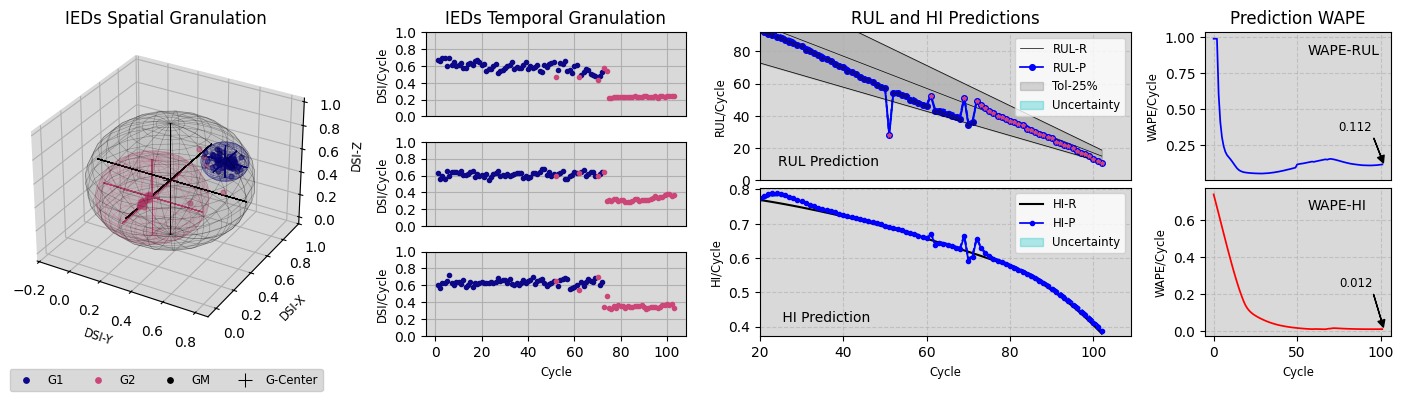

In [2]:
params =  [2.0, 5, '[58, 11, 64, 31, 32]', 15, 5, 0.0754386941522406,6.688979613494848e-06, 0.0029919547064531, 10.168345750070529,'ahead', 'tanh']

m,nI,nR,nO,mO,N1,N2,N3,τ,mode,act = params
X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)
nI = len(Y[0])
if isinstance(nR, str): nR = ast.literal_eval(nR)

teda=AutoCloud(m=m,nI=nI,nR=nR,nO=nO+mO,ηS=[N1,N2,N3],mode=mode,act=act,
               tau=τ,rho=0.001,eol=0.3,ref=len(sig)-nI+1,wtaG=True,wtaP=True) 
for j,_ in enumerate(X[:]):
    teda.run(X[j])
    teda.RUL_Prediction(Y[j],mode='interval',lim=len(sig)-nI+1,show=False)
    teda.WAPE_HI2(Y[j],Z[j])
    teda.Adapt(Y[j],Z[j])

teda.c = np.append(teda.c,teda.gm)  
PlotDSI_3D_PLT(teda)


In [3]:
print(xxx)

NameError: name 'xxx' is not defined

In [4]:
def OptimizeParams(SingleObj=True,FileName=None,n_study=1,timeout=60,n_trials=25,nMax=20,mS=[1.75,4.25],nIS=[2,None],nLS=[1,5],nRS=[1,60],nOS=[1,None],mOS=[0,None],
                   N1S=[1,9],N2S=[1,9],N3S=[1,9],τS=[1,25],mdS=[1,1],actS=[0,1]):

    if SingleObj: names = ['MAPE_RUL*MAPE_HI', 'm', 'nI', 'nR', 'nO', 'mO', 'N1', 'N2', 'N3','TAU','past/ahead','activation']
    else: names = ['MAPE_RUL','MAPE_HI', 'm', 'nI', 'nR', 'nO', 'mO', 'N1', 'N2', 'N3','TAU','past/ahead','activation']
    study_dir, out_path = df_ParamsTable(names,FileName)

    df2 = []

    nS = [nIS,nOS,mOS]
    for i,n in enumerate(nS):
        if n[1] == None: nS[i][1] = 20
    nIS,nOS,mOS = nS

    for i in range(n_study):
        print('iteration:',i+1)
        def objective(trial):
            m = trial.suggest_float('m', mS[0], mS[1],step=0.25)
            nI = trial.suggest_int('nI', nIS[0], nIS[1]) 
            n_layers = trial.suggest_int('n_layers', nLS[0], nLS[1])
            nR = [trial.suggest_int(f'nR_layer_{l}', nRS[0], nRS[1]) for l in range(n_layers)]
            nO = trial.suggest_int('nO', nOS[0], nOS[1]) 
            mO = trial.suggest_int('mO', mOS[0], mOS[1]) 
            N1 = trial.suggest_int('N1', N1S[0], N1S[1])
            N2 = trial.suggest_int('N2', N2S[0], N2S[1])
            N3 = trial.suggest_int('N3', N3S[0], N3S[1])
            τ = trial.suggest_float('τ', τS[0], τS[1],log=True)
            mode = trial.suggest_int('mode', mdS[0], mdS[1])  
            act = trial.suggest_int('act', actS[0], actS[1])  

            if mode == 'past':
                if nO > nI: raise TrialPruned()
            elif mode == 'ahead':
                if nI> nMax or nO> nMax: raise TrialPruned()
                elif mO > nI: raise TrialPruned()
                
            X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)
            nI = len(Y[0])
            
            teda=AutoCloud(m=m,nI=nI,nR=nR,nO=nO+mO,ηS=[N1,N2,N3],mode=mode,act=act,
                        tau=τ,rho=0.0,eol=0.3,ref=len(sig)-nI+1,wtaG=True,wtaP=True) 
            for j,_ in enumerate(X[:]):
                teda.run(X[j])
                teda.RUL_Prediction(Y[j],mode='single',lim=len(sig)-nI+1)
                teda.Adapt(Y[j],Z[j])
                #teda.WAPE_HI2(Y[j],Z[j])

                if np.isinf(teda.hiP[-1]) or np.isnan(teda.hiP[-1]): raise TrialPruned()

                if j >=60 and j%5==0:
                    if teda.wape_RUL > 0.6: raise TrialPruned()
                    if teda.wape_HI  > 0.3: raise TrialPruned()

                if SingleObj and j%35==0:
                    trial.report(teda.wape_RUL+teda.wape_HI, j)
                    if trial.should_prune():
                        raise optuna.TrialPruned()

            if SingleObj: return teda.wape_RUL + teda.wape_HI
            else: return teda.wape_RUL,teda.wape_HI

        pruner=optuna.pruners.HyperbandPruner()
        early_stopping = EarlyStoppingCallback(patience=int(n_trials*0.05))
        if SingleObj: study = optuna.create_study(direction='minimize',pruner=pruner,sampler=SelSampler(mode='tpe'))
        else: study = optuna.create_study(directions=['minimize','minimize'],sampler=SelSampler(mode='auto'))
        study.optimize(objective, n_trials=n_trials, timeout=timeout, callbacks=[early_stopping])
    
    
        for trial in study.best_trials:
            p = trial.params
            nR_list = [p[f'nR_layer_{l}'] for l in range(p['n_layers'])]
            if SingleObj:
                row = [trial.values[0],p['m'],p['nI'],str(nR_list),p['nO'],p['mO'],p['N1'],p['N2'],p['N3'],p['τ'],p['mode'],p['act']]   
            else:
                row = [trial.values[0],trial.values[1],p['m'],p['nI'],str(nR_list),p['nO'],p['mO'],p['N1'],p['N2'],p['N3'],p['τ'],p['mode'],p['act']]
            df2.append(row)
    
    df2 = pd.DataFrame(df2, columns=names)
    
    if os.path.isfile(out_path) and out_path.startswith(study_dir):
        df1 = pd.read_csv(out_path)
        df_stdy = pd.concat([df1, df2], ignore_index=True)
    
    else: df_stdy = df2
    
    df_stdy.to_csv(out_path, index=False)
    opt_path = os.path.join(study_dir,f'opt_{len(os.listdir(study_dir))-1}.csv')
    df2.to_csv(opt_path, index=False)

    return out_path, opt_path      

In [ ]:
out_path, opt_path = OptimizeParams(SingleObj=True,FileName=FileName,n_study=1,timeout=2400,n_trials=20000,
                    nMax=20,mS=[1.75,4.25], nIS=[2,None],nLS=[1,5],nRS=[1,60],nOS=[1,None],mOS=[0,None],
                    N1S=[1,9],N2S=[1,9],N3S=[1,9],τS=[1,25],mdS=[1,1],actS=[0,1])   

In [ ]:
for i in range(1,6):
    out_path, opt_path = OptimizeParams(SingleObj=True,FileName=FileName,n_study=5,timeout=2400,n_trials=20000,
                    nMax=20,mS=[1.75,4.25], nIS=[2,None],nLS=[i,i],nRS=[1,60],nOS=[1,None],mOS=[0,None],
                    N1S=[1,9],N2S=[1,9],N3S=[1,9],τS=[1,25],mdS=[1,1],actS=[0,1])   

In [ ]:
#out_path = 'Optimization\\eDRTLO_GD_R02_mono\\Optimization.csv'
df_params = pd.read_csv(out_path)
#df_params = pd.read_csv(opt_path)
#df_params = df_params[(df_params.iloc[:,0] <= 0.10)]
params_list = df_params.values[:,-11:]
df_params

In [ ]:
for i,params in enumerate(params_list):
    m,nI,nR,nO,mO,N1,N2,N3,τ,mode,act = params
    X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)
    nI=len(Y[0])
    if isinstance(nR, str): nR = ast.literal_eval(nR)

    teda=AutoCloud(m=m,nI=nI,nR=nR,nO=nO+mO,ηS=[N1,N2,N3],mode=mode,act=act,
                tau=τ,rho=0.001,eol=0.3,ref=len(sig)-nI+1,wtaG=True,wtaP=True) 
    for j,_ in enumerate(X[:]):
        teda.run(X[j])
        teda.RUL_Prediction(Y[j],mode='interval',lim=len(sig)-nI+1,show=False)
        teda.Adapt(Y[j],Z[j])

    teda.c = np.append(teda.c,teda.gm)  
    #PlotSeriesPLY(ySeries=[teda.wape_HI_hist,teda.wape_RUL_hist])
    PlotDSI_3D_PLT(teda)

In [ ]:
m,nI,nR,nO,mO,N1,N2,N3,τ,mode,act = params_list[1]
X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)
nI = len(Y[0])
if isinstance(nR, str): nR = ast.literal_eval(nR)
n1,n2,n3 = (1/(10**N1)),(1/(10**N2)),(1/(10**N3))

teda=AutoCloud(m=m,nI=nI,nR=nR,nO=nO+mO,ηS=[n1,n2,n3],mode=mode,act=act,
               tau=τ,rho=0.001,eol=0.3,ref=len(sig)-nI+1,wtaG=True,wtaP=True) 
for j,_ in enumerate(X[:]):
    teda.run(X[j])
    teda.RUL_Prediction(Y[j],mode='interval',lim=len(sig)-nI+1,show=False)
    teda.Adapt(Y[j],Z[j])
teda.c = np.append(teda.c,teda.gm)  
PlotDSI_3D_PLT(teda)